# Notebook 2 — SQL in R & R Analytics
## NorthStar Urban Mobility and Logistics — Case Study
---
**What this notebook does:**
- Runs SQL queries using RSQLite inside R to find business problems
- Performs statistical analysis with dplyr and tidyr
- Produces publication-ready charts with ggplot2


## Section 1 — Install & Load Packages

In [1]:
# Install packages needed
install.packages("RSQLite",   quiet = TRUE)
install.packages("DBI",       quiet = TRUE)
install.packages("dplyr",     quiet = TRUE)
install.packages("ggplot2",   quiet = TRUE)
install.packages("tidyr",     quiet = TRUE)
install.packages("scales",    quiet = TRUE)
install.packages("gridExtra", quiet = TRUE)
install.packages("corrplot",  quiet = TRUE)

cat("All packages installed.\n")

All packages installed.


In [28]:
# Load all libraries
library(DBI)
library(RSQLite)
library(dplyr)
library(ggplot2)
library(tidyr)
library(scales)
library(gridExtra)
library(corrplot)

# Clean ggplot2 theme for all charts
theme_set(theme_minimal(base_size = 12) +
          theme(plot.title    = element_text(face = "bold", size = 13),
                axis.text     = element_text(size = 10),
                legend.position = "bottom"))

cat("All libraries loaded.\n")

All libraries loaded.


## Section 2 — Upload Clean CSV Files


In [29]:
# Colab file upload for R
library(jsonlite)

# This triggers the Colab file picker
files_uploaded <- file.choose()

In [30]:
# Read all clean CSV files
hubs        <- read.csv("hubs_clean.csv",       stringsAsFactors = FALSE)
customers   <- read.csv("customers_clean.csv",   stringsAsFactors = FALSE)
drivers     <- read.csv("drivers_clean.csv",     stringsAsFactors = FALSE)
vehicles    <- read.csv("vehicles_clean.csv",    stringsAsFactors = FALSE)
orders      <- read.csv("orders_clean.csv",      stringsAsFactors = FALSE)
deliveries  <- read.csv("deliveries_clean.csv",  stringsAsFactors = FALSE)
incidents   <- read.csv("incidents_clean.csv",   stringsAsFactors = FALSE)
complaints  <- read.csv("complaints_clean.csv",  stringsAsFactors = FALSE)
app_events  <- read.csv("app_events_clean.csv",  stringsAsFactors = FALSE)

cat("Files loaded:\n")
for (nm in c("hubs","customers","drivers","vehicles","orders",
             "deliveries","incidents","complaints","app_events")) {
  df <- get(nm)
  cat(sprintf("  %-15s %d rows x %d cols\n", nm, nrow(df), ncol(df)))
}

Files loaded:
  hubs            8 rows x 5 cols
  customers       650 rows x 11 cols
  drivers         170 rows x 8 cols
  vehicles        120 rows x 9 cols
  orders          1250 rows x 11 cols
  deliveries      950 rows x 15 cols
  incidents       280 rows x 7 cols
  complaints      320 rows x 10 cols
  app_events      640 rows x 10 cols


## Section 3 — Load All Data into SQLite Database

In [31]:
# Create an in-memory SQLite database
con <- dbConnect(RSQLite::SQLite(), dbname = ":memory:")

In [32]:
# Write every dataframe as a table in the database
dbWriteTable(con, "hubs",       hubs,       overwrite = TRUE)
dbWriteTable(con, "customers",  customers,  overwrite = TRUE)
dbWriteTable(con, "drivers",    drivers,    overwrite = TRUE)
dbWriteTable(con, "vehicles",   vehicles,   overwrite = TRUE)
dbWriteTable(con, "orders",     orders,     overwrite = TRUE)
dbWriteTable(con, "deliveries", deliveries, overwrite = TRUE)
dbWriteTable(con, "incidents",  incidents,  overwrite = TRUE)
dbWriteTable(con, "complaints", complaints, overwrite = TRUE)
dbWriteTable(con, "app_events", app_events, overwrite = TRUE)

In [33]:
# Verify all tables are present
cat("Tables in SQLite database:\n")
print(dbListTables(con))

Tables in SQLite database:
[1] "app_events" "complaints" "customers"  "deliveries" "drivers"   
[6] "hubs"       "incidents"  "orders"     "vehicles"  


## Section 4 — SQL Queries
### SQL Query 1 — Overall Delivery Performance

In [36]:
# SQL Query 1: Overall delivery status counts and percentages
q1 <- dbGetQuery(con, "
  SELECT
    delivery_status                                    AS Status,
    COUNT(*)                                           AS Total,
    ROUND(COUNT(*) * 100.0 / (SELECT COUNT(*) FROM deliveries), 1) AS Percentage
  FROM deliveries
  GROUP BY delivery_status
  ORDER BY Total DESC
")

cat("Query 1 — Overall Delivery Performance:\n")
q1

Query 1 — Overall Delivery Performance:


Status,Total,Percentage
<chr>,<int>,<dbl>
OnTime,616,64.8
Delayed,202,21.3
Failed,132,13.9


### SQL Query 2 — Hub Performance with Failure Rates

In [37]:
# SQL Query 2: Join deliveries with hubs to get performance per hub
# Using CASE WHEN to compute conditional counts in one pass
q2 <- dbGetQuery(con, "
  SELECT
    h.hub_id,
    h.hub_name,
    h.zone,
    h.hub_type,
    COUNT(d.delivery_id)                                           AS total_deliveries,
    SUM(CASE WHEN d.delivery_status = 'OnTime'  THEN 1 ELSE 0 END) AS on_time,  -- 'OnTime' is the correct value from cleaned data
    SUM(CASE WHEN d.delivery_status = 'Delayed' THEN 1 ELSE 0 END) AS delayed,
    SUM(CASE WHEN d.delivery_status = 'Failed'  THEN 1 ELSE 0 END) AS failed,
    ROUND(SUM(CASE WHEN d.delivery_status = 'Failed' THEN 1 ELSE 0 END)
          * 100.0 / COUNT(d.delivery_id), 1)                       AS failure_rate_pct,
    ROUND(AVG(d.manual_route_override_count), 2)                   AS avg_overrides
  FROM deliveries d
  JOIN hubs h ON d.hub_id = h.hub_id
  GROUP BY h.hub_id, h.hub_name, h.zone, h.hub_type
  ORDER BY failure_rate_pct DESC
")

In [40]:
cat("Query 2 — Hub Performance (sorted by failure rate):\n\n")
q2
cat("\nInterpretation: H05 (Central Core) and H08 (Midtown Relay) have the highest failure rates.\n")
cat("These two hubs account for a disproportionate share of failed deliveries.\n")

Query 2 — Hub Performance (sorted by failure rate):



hub_id,hub_name,zone,hub_type,total_deliveries,on_time,delayed,failed,failure_rate_pct,avg_overrides
<chr>,<chr>,<chr>,<chr>,<int>,<int>,<int>,<int>,<dbl>,<dbl>
H08,Midtown Relay,Central,Charging,128,80,22,26,20.3,1.11
H05,Central Core,Central,Control,115,67,25,23,20.0,0.95
H06,Airport Hub,Airport,Dispatch,104,62,27,15,14.4,0.91
H04,West Gate,West,Dispatch,127,83,28,16,12.6,0.87
H01,North Exchange,North,Dispatch,136,93,26,17,12.5,1.03
H07,Riverside Hub,Riverside,Warehouse,115,76,25,14,12.2,1.05
H02,South Link,South,Dispatch,106,70,26,10,9.4,0.92
H03,East Dock,East,Warehouse,119,85,23,11,9.2,0.89



Interpretation: H05 (Central Core) and H08 (Midtown Relay) have the highest failure rates.
These two hubs account for a disproportionate share of failed deliveries.


### SQL Query 3 — The OnTime/Complaint Mismatch

In [8]:
# SQL Query 3: Find deliveries marked OnTime that still received complaints
# This is the critical data integrity problem — system says fine, customer says otherwise
q3 <- dbGetQuery(con, "
  SELECT
    d.delivery_id,
    d.order_id,
    d.delivery_status,
    c.complaint_type,
    c.severity,
    c.status       AS complaint_status,
    c.resolution_days,
    c.compensation_amount
  FROM deliveries d
  JOIN complaints c ON d.order_id = c.order_id
  WHERE d.delivery_status = 'OnTime'
  ORDER BY c.severity DESC, c.compensation_amount DESC
")

cat(sprintf("Query 3 — OnTime deliveries with complaints: %d cases\n\n", nrow(q3)))

# Summary by complaint type
q3_summary <- dbGetQuery(con, "
  SELECT
    c.complaint_type,
    COUNT(*) AS count,
    ROUND(AVG(c.compensation_amount), 2) AS avg_compensation
  FROM deliveries d
  JOIN complaints c ON d.order_id = c.order_id
  WHERE d.delivery_status = 'OnTime'
  GROUP BY c.complaint_type
  ORDER BY count DESC
")
print(q3_summary)
cat("\nInterpretation: 149 OnTime deliveries generated complaints.\n")
cat("This proves the data fragmentation the CX Director described —\n")
cat("the delivery system and customer complaint system are not connected.\n")

Query 3 — OnTime deliveries with complaints: 149 cases

     complaint_type count avg_compensation
1             Delay    44            17.15
2   DriverBehaviour    29            18.54
3      MissedPickup    25            21.33
4          AppIssue    25            17.80
5 SupportExperience    11            13.88
6            Damage     8            24.55
7           Billing     7            20.22

Interpretation: 149 OnTime deliveries generated complaints.
This proves the data fragmentation the CX Director described —
the delivery system and customer complaint system are not connected.


### SQL Query 4 — Service Type Profitability

In [41]:
# SQL Query 4: Join orders + deliveries to calculate a margin proxy per service type
# Also shows failure rates — combining financial and operational data
q4 <- dbGetQuery(con, "
  SELECT
    o.service_type,
    COUNT(*)                                                              AS total,
    ROUND(AVG(o.order_value), 2)                                          AS avg_order_value,
    ROUND(AVG(d.fuel_or_charge_cost), 2)                                  AS avg_fuel_cost,
    ROUND(AVG(o.order_value - d.fuel_or_charge_cost), 2)                  AS avg_margin_proxy,
    SUM(CASE WHEN d.delivery_status = 'Failed' THEN 1 ELSE 0 END)         AS failed_count,
    ROUND(SUM(CASE WHEN d.delivery_status = 'Failed' THEN 1 ELSE 0 END)
          * 100.0 / COUNT(*), 1)                                           AS failure_rate_pct,
    ROUND(SUM(CASE WHEN d.delivery_status = 'Failed' THEN 1 ELSE 0 END)
          * AVG(o.order_value - d.fuel_or_charge_cost), 2)                 AS estimated_loss
  FROM orders o
  JOIN deliveries d ON o.order_id = d.order_id
  GROUP BY o.service_type
  ORDER BY avg_margin_proxy ASC
")

cat("Query 4 — Service Type Profitability vs Failure Rate:\n")
q4
cat("\nInterpretation: Medical and Retail have the lowest margins.\n")
cat("Medical also has a significant failure rate — low revenue plus high failure cost.\n")

Query 4 — Service Type Profitability vs Failure Rate:


service_type,total,avg_order_value,avg_fuel_cost,avg_margin_proxy,failed_count,failure_rate_pct,estimated_loss
<chr>,<int>,<dbl>,<dbl>,<dbl>,<int>,<dbl>,<dbl>
Medical,108,86.53,12.77,73.75,16,14.8,1180.06
Retail,224,86.81,12.97,73.83,28,12.5,2067.32
Parcel,230,90.15,13.08,77.07,25,10.9,1926.79
Business,126,97.45,13.14,84.31,25,19.8,2107.80
Passenger,262,97.19,12.40,84.79,38,14.5,3221.99



Interpretation: Medical and Retail have the lowest margins.
Medical also has a significant failure rate — low revenue plus high failure cost.


### SQL Query 5 — Vehicle Fault Detection Failure

In [42]:
# SQL Query 5: Vehicles that are InRepair and still generating BatteryAlert incidents
# This proves maintenance faults are being detected too late
q5 <- dbGetQuery(con, "
  SELECT
    v.vehicle_id,
    v.vehicle_type,
    v.battery_health_pct,
    v.maintenance_status,
    v.odometer_km,
    i.incident_type,
    i.severity,
    i.resolution_status,
    i.resolved_hours
  FROM vehicles v
  JOIN deliveries d  ON v.vehicle_id = d.vehicle_id
  JOIN incidents  i  ON d.delivery_id = i.delivery_id
  WHERE v.maintenance_status = 'InRepair'
    AND i.incident_type IN ('BatteryAlert', 'VehicleFault')
  ORDER BY v.battery_health_pct ASC
")

cat(sprintf("Query 5 — InRepair vehicles still triggering fault incidents: %d cases\n\n", nrow(q5)))
q5
cat("\nInterpretation: Vehicles already flagged InRepair are still being deployed\n")
cat("and generating BatteryAlert/VehicleFault incidents on active routes.\n")
cat("This confirms the Technology Director's concern about late fault detection.\n")

Query 5 — InRepair vehicles still triggering fault incidents: 27 cases



vehicle_id,vehicle_type,battery_health_pct,maintenance_status,odometer_km,incident_type,severity,resolution_status,resolved_hours
<chr>,<chr>,<dbl>,<chr>,<int>,<chr>,<chr>,<chr>,<dbl>
V084,CargoVan,47.6,InRepair,53872,VehicleFault,Low,Open,7.1
V108,Diesel,54.6,InRepair,141290,BatteryAlert,Low,Open,9.6
V108,Diesel,54.6,InRepair,141290,VehicleFault,Low,PendingVendor,10.9
V108,Diesel,54.6,InRepair,141290,BatteryAlert,High,Open,1.7
V108,Diesel,54.6,InRepair,141290,BatteryAlert,Low,Closed,10.2
V037,CargoVan,56.6,InRepair,52146,BatteryAlert,Medium,Open,12.2
V113,Hybrid,58.9,InRepair,52725,BatteryAlert,Low,Closed,4.7
V109,Hybrid,60.6,InRepair,193552,BatteryAlert,Medium,Escalated,26.8
V070,CargoVan,62.6,InRepair,39859,BatteryAlert,Medium,Closed,24.3



Interpretation: Vehicles already flagged InRepair are still being deployed
and generating BatteryAlert/VehicleFault incidents on active routes.
This confirms the Technology Director's concern about late fault detection.


### SQL Query 6 — Driver Override Behaviour

In [43]:
# SQL Query 6: Driver override rates joined with their training and rating
# Do poorly trained drivers override more? Or is it a route planning problem?
q6 <- dbGetQuery(con, "
  SELECT
    dr.driver_id,
    dr.base_zone,
    dr.employment_type,
    ROUND(dr.training_score, 1)                    AS training_score,
    ROUND(dr.driver_rating, 2)                     AS driver_rating,
    COUNT(d.delivery_id)                           AS total_deliveries,
    SUM(d.manual_route_override_count)             AS total_overrides,
    ROUND(AVG(d.manual_route_override_count), 2)   AS avg_overrides_per_delivery,
    SUM(CASE WHEN d.delivery_status = 'Failed' THEN 1 ELSE 0 END) AS failed_deliveries
  FROM drivers dr
  JOIN deliveries d ON dr.driver_id = d.driver_id
  GROUP BY dr.driver_id
  HAVING total_deliveries >= 3
  ORDER BY avg_overrides_per_delivery DESC
  LIMIT 20
")

cat("Query 6 — Top 20 drivers by average route overrides:\n")
q6

Query 6 — Top 20 drivers by average route overrides:


driver_id,base_zone,employment_type,training_score,driver_rating,total_deliveries,total_overrides,avg_overrides_per_delivery,failed_deliveries
<chr>,<chr>,<chr>,<dbl>,<dbl>,<int>,<int>,<dbl>,<int>
D127,Central,FullTime,61.5,4.19,6,17,2.83,0
D139,South,FullTime,71.4,4.99,5,10,2.00,0
D130,West,FullTime,71.2,3.64,8,16,2.00,1
D124,North,FullTime,70.6,3.78,4,8,2.00,0
D105,Riverside,Contract,82.0,3.71,7,14,2.00,1
D085,North,PartTime,84.5,4.11,4,8,2.00,0
D069,North,PartTime,61.5,5.00,7,14,2.00,1
D062,South,FullTime,62.4,4.48,3,6,2.00,1
D028,North,FullTime,83.0,4.07,7,13,1.86,1


In [44]:
# Query 6b: Correlation check — does training score predict override frequency?
q6b <- dbGetQuery(con, "
  SELECT
    ROUND(dr.training_score / 20) * 20       AS training_band,
    COUNT(d.delivery_id)                      AS deliveries,
    ROUND(AVG(d.manual_route_override_count), 2) AS avg_overrides
  FROM drivers dr
  JOIN deliveries d ON dr.driver_id = d.driver_id
  GROUP BY training_band
  ORDER BY training_band
")
cat("\nQuery 6b — Override rate by training score band:\n")
q6b
cat("\nInterpretation: Weak correlation between training and overrides.\n")
cat("Override behaviour is more likely route planning failure than driver skill.\n")


Query 6b — Override rate by training score band:


training_band,deliveries,avg_overrides
<dbl>,<int>,<dbl>
40,28,0.82
60,246,0.92
80,611,0.99
100,65,0.98



Interpretation: Weak correlation between training and overrides.
Override behaviour is more likely route planning failure than driver skill.


### SQL Query 7 — Zone Failure Rate (after standardisation)

In [45]:
# SQL Query 7: Failure rates by pickup zone
q7 <- dbGetQuery(con, "
  SELECT
    o.pickup_zone                                                          AS zone,
    COUNT(d.delivery_id)                                                   AS total_deliveries,
    SUM(CASE WHEN d.delivery_status = 'OnTime'  THEN 1 ELSE 0 END)         AS on_time,  -- 'OnTime' matches cleaned data
    SUM(CASE WHEN d.delivery_status = 'Delayed' THEN 1 ELSE 0 END)         AS delayed,
    SUM(CASE WHEN d.delivery_status = 'Failed'  THEN 1 ELSE 0 END)         AS failed,
    ROUND(SUM(CASE WHEN d.delivery_status = 'Failed' THEN 1 ELSE 0 END)
          * 100.0 / COUNT(*), 1)                                           AS failure_rate_pct,
    ROUND(AVG(o.order_value), 2)                                           AS avg_order_value
  FROM orders o
  JOIN deliveries d ON o.order_id = d.order_id
  GROUP BY o.pickup_zone
  ORDER BY failure_rate_pct DESC
")

cat("Query 7 — Zone Performance (sorted by failure rate):\n")
q7
cat("\nInterpretation: Central and Riverside zones have the highest failure rates.\n")

Query 7 — Zone Performance (sorted by failure rate):


zone,total_deliveries,on_time,delayed,failed,failure_rate_pct,avg_order_value
<chr>,<int>,<int>,<int>,<int>,<dbl>,<dbl>
Central,174,90,51,33,19.0,87.83
North,135,92,21,22,16.3,90.23
Riverside,119,76,25,18,15.1,90.28
West,114,79,21,14,12.3,89.05
East,156,106,31,19,12.2,93.44
Airport,113,70,31,12,10.6,101.72
South,139,103,22,14,10.1,92.37



Interpretation: Central and Riverside zones have the highest failure rates.


### SQL Query 8 — Repeat Complainers

In [46]:
# SQL Query 8: Customers with multiple complaints — who are the repeat complainers?

q8 <- dbGetQuery(con, "
  SELECT
    c.customer_id,
    cu.customer_type,
    cu.home_zone,
    cu.account_status,
    COUNT(c.complaint_id)                  AS complaint_count,
    GROUP_CONCAT(DISTINCT c.complaint_type) AS complaint_types,
    ROUND(SUM(c.compensation_amount), 2)   AS total_compensation,
    ROUND(AVG(c.resolution_days), 1)       AS avg_resolution_days
  FROM complaints c
  JOIN customers cu ON c.customer_id = cu.customer_id
  GROUP BY c.customer_id
  HAVING complaint_count >= 2
  ORDER BY complaint_count DESC, total_compensation DESC
  LIMIT 15
")

cat(sprintf("Query 8 — Repeat complainers (2+ complaints): %d customers\n\n", nrow(q8)))
q8

Query 8 — Repeat complainers (2+ complaints): 15 customers



customer_id,customer_type,home_zone,account_status,complaint_count,complaint_types,total_compensation,avg_resolution_days
<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<dbl>,<dbl>
C0368,Consumer,North,Active,4,"Delay,AppIssue,SupportExperience",77.51,8.5
C0421,Consumer,Central,Active,3,"MissedPickup,Billing,DriverBehaviour",118.98,9.7
C0573,SME,Airport,Active,3,"Billing,Delay",111.42,10.7
C0242,Consumer,East,Active,3,"Delay,DriverBehaviour",75.75,8.3
C0282,Consumer,Riverside,Active,3,"Delay,DriverBehaviour",74.63,7.0
C0545,Consumer,South,Active,3,"Billing,DriverBehaviour,AppIssue",73.60,12.3
C0372,Consumer,West,Active,3,"AppIssue,Delay,MissedPickup",71.89,8.0
C0191,Consumer,North,Active,3,"Delay,AppIssue",62.76,6.3
C0172,Consumer,North,Active,3,"MissedPickup,SupportExperience",61.49,5.3


### SQL Query 9 — Optimised Query with Index Hint (Query Optimisation)

In [47]:
# SQL Query 9: Demonstrate query optimisation awareness
# First create an index on the most-joined columns, then show the benefit

# Create indexes on key foreign key / filter columns
dbExecute(con, "CREATE INDEX IF NOT EXISTS idx_deliveries_order   ON deliveries(order_id)")
dbExecute(con, "CREATE INDEX IF NOT EXISTS idx_deliveries_hub     ON deliveries(hub_id)")
dbExecute(con, "CREATE INDEX IF NOT EXISTS idx_deliveries_driver  ON deliveries(driver_id)")
dbExecute(con, "CREATE INDEX IF NOT EXISTS idx_deliveries_status  ON deliveries(delivery_status)")
dbExecute(con, "CREATE INDEX IF NOT EXISTS idx_complaints_order   ON complaints(order_id)")
dbExecute(con, "CREATE INDEX IF NOT EXISTS idx_incidents_delivery ON incidents(delivery_id)")
dbExecute(con, "CREATE INDEX IF NOT EXISTS idx_orders_service     ON orders(service_type)")
dbExecute(con, "CREATE INDEX IF NOT EXISTS idx_orders_zone        ON orders(pickup_zone)")

cat("Indexes created on all key join and filter columns.\n")
cat("\nOptimised multi-table query — joins 4 tables using indexed columns:\n")

q9 <- dbGetQuery(con, "
  SELECT
    h.hub_name,
    o.service_type,
    o.priority_level,
    COUNT(d.delivery_id)                                                   AS deliveries,
    ROUND(AVG(d.fuel_or_charge_cost), 2)                                   AS avg_cost,
    ROUND(AVG(o.order_value - d.fuel_or_charge_cost), 2)                   AS avg_margin,
    SUM(CASE WHEN d.delivery_status = 'Failed' THEN 1 ELSE 0 END)          AS failures,
    COUNT(DISTINCT c.complaint_id)                                          AS complaints
  FROM orders o
  JOIN deliveries  d ON o.order_id    = d.order_id     -- indexed
  JOIN hubs        h ON d.hub_id      = h.hub_id
  LEFT JOIN complaints c ON o.order_id = c.order_id   -- indexed
  GROUP BY h.hub_name, o.service_type, o.priority_level
  HAVING deliveries >= 5
  ORDER BY failures DESC, avg_margin ASC
  LIMIT 20
")

cat("\nResult — Hub + Service + Priority breakdown:\n")
q9

[1] 0

[1] 0

[1] 0

[1] 0

[1] 0

[1] 0

[1] 0

[1] 0

Indexes created on all key join and filter columns.

Optimised multi-table query — joins 4 tables using indexed columns:

Result — Hub + Service + Priority breakdown:


hub_name,service_type,priority_level,deliveries,avg_cost,avg_margin,failures,complaints
<chr>,<chr>,<chr>,<int>,<dbl>,<dbl>,<int>,<int>
Midtown Relay,Passenger,Low,22,10.88,96.49,6,7
Central Core,Parcel,Medium,18,13.45,90.66,5,5
Midtown Relay,Passenger,Medium,17,10.73,74.13,4,6
Midtown Relay,Business,Medium,8,13.89,79.68,4,2
North Exchange,Business,Medium,7,11.51,48.84,3,1
West Gate,Passenger,Medium,17,12.59,57.98,3,2
West Gate,Retail,Medium,12,12.94,59.60,3,2
North Exchange,Passenger,Medium,23,12.21,63.79,3,3
Airport Hub,Parcel,Medium,16,12.59,78.16,3,0


## Section 5 — R Analytics & Visualisations

### Chart 1 — Hub Failure Rate Bar Chart

Chart saved.


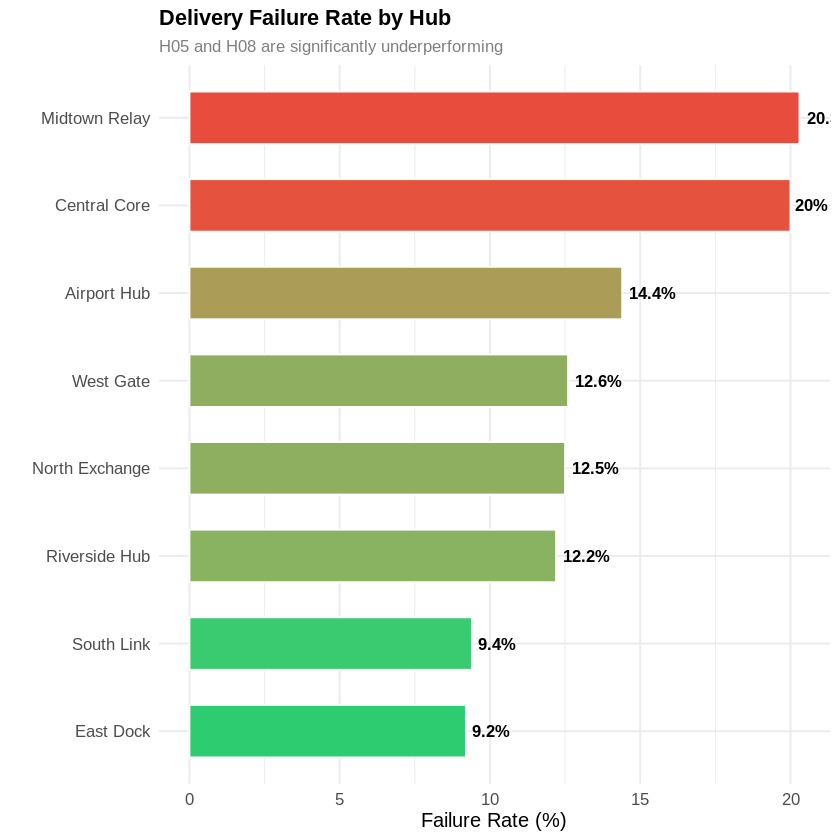

In [16]:
# Use the hub performance data from SQL Query 2
hub_data <- q2

# Reorder hub names by failure rate for clean chart
hub_data$hub_name <- factor(hub_data$hub_name,
                             levels = hub_data$hub_name[order(hub_data$failure_rate_pct)])

p1 <- ggplot(hub_data, aes(x = hub_name, y = failure_rate_pct,
                            fill = failure_rate_pct)) +
  geom_bar(stat = "identity", width = 0.6, colour = "white") +
  geom_text(aes(label = paste0(failure_rate_pct, "%")),
            hjust = -0.15, size = 3.5, fontface = "bold") +
  scale_fill_gradient(low = "#2ecc71", high = "#e74c3c", guide = "none") +
  coord_flip() +
  labs(title    = "Delivery Failure Rate by Hub",
       subtitle = "H05 and H08 are significantly underperforming",
       x = NULL, y = "Failure Rate (%)") +
  theme(plot.subtitle = element_text(size = 10, colour = "grey50"))

print(p1)
ggsave("r_chart1_hub_failure.png", p1, width = 8, height = 4.5, dpi = 150)
cat("Chart saved.\n")

### Chart 2 — Delivery Status Stacked Bar by Hub

Chart saved.


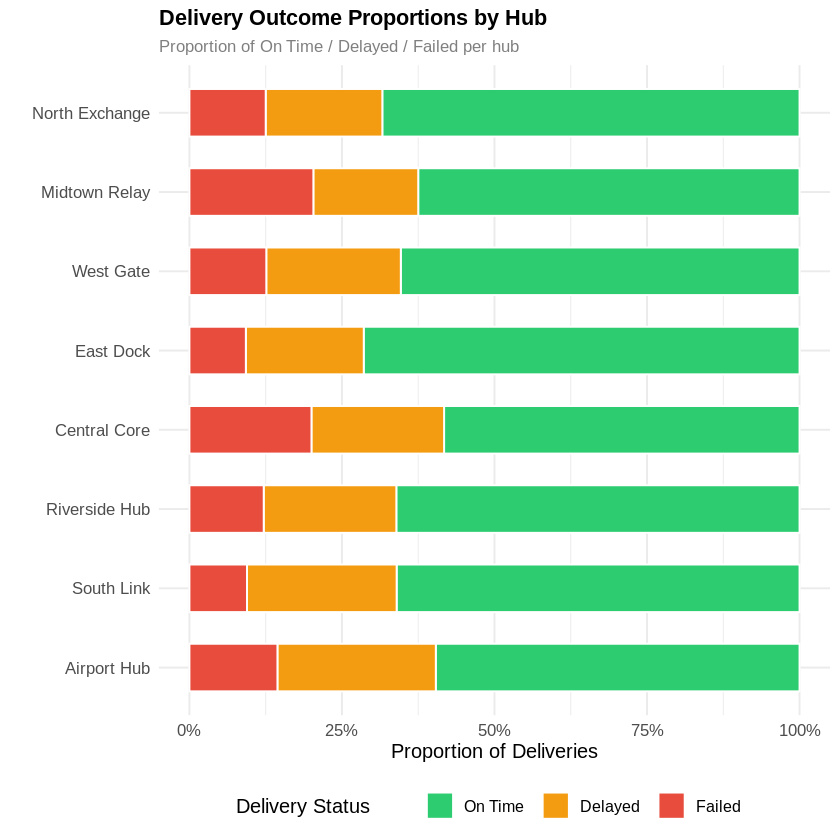

In [17]:
# Pivot hub data to long format for stacked bars
hub_long <- hub_data %>%
  select(hub_name, on_time, delayed, failed) %>%
  pivot_longer(cols = c(on_time, delayed, failed),
               names_to = "status", values_to = "count")

# Clean status labels
hub_long$status <- factor(hub_long$status,
                           levels = c("on_time","delayed","failed"),
                           labels = c("On Time","Delayed","Failed"))

p2 <- ggplot(hub_long, aes(x = reorder(hub_name, count), y = count, fill = status)) +
  geom_bar(stat = "identity", position = "fill", width = 0.6, colour = "white") +
  scale_fill_manual(values = c("On Time" = "#2ecc71",
                               "Delayed" = "#f39c12",
                               "Failed"  = "#e74c3c"),
                    name = "Delivery Status") +
  scale_y_continuous(labels = percent_format()) +
  coord_flip() +
  labs(title    = "Delivery Outcome Proportions by Hub",
       subtitle = "Proportion of On Time / Delayed / Failed per hub",
       x = NULL, y = "Proportion of Deliveries") +
  theme(plot.subtitle = element_text(size = 10, colour = "grey50"))

print(p2)
ggsave("r_chart2_hub_stacked.png", p2, width = 9, height = 5, dpi = 150)
cat("Chart saved.\n")

### Chart 3 — Service Type: Margin vs Failure Rate Scatter

Chart saved.


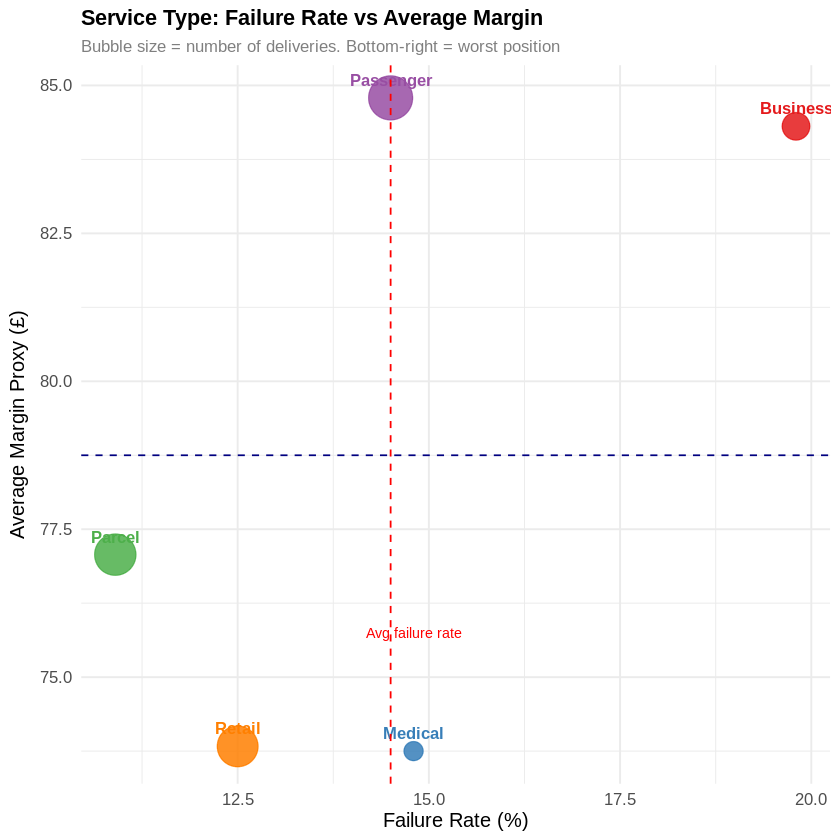

In [18]:
# This chart shows the Finance Director's concern visually
# Low margin + high failure = service is losing money

p3 <- ggplot(q4, aes(x = failure_rate_pct, y = avg_margin_proxy,
                      colour = service_type, size = total)) +
  geom_point(alpha = 0.85) +
  geom_text(aes(label = service_type), vjust = -1, size = 3.5, fontface = "bold") +
  scale_colour_brewer(palette = "Set1", guide = "none") +
  scale_size_continuous(range = c(5, 12), guide = "none") +
  labs(title    = "Service Type: Failure Rate vs Average Margin",
       subtitle = "Bubble size = number of deliveries. Bottom-right = worst position",
       x = "Failure Rate (%)", y = "Average Margin Proxy (£)") +
  geom_hline(yintercept = mean(q4$avg_margin_proxy), linetype = "dashed",
             colour = "navy", linewidth = 0.5) +
  geom_vline(xintercept = mean(q4$failure_rate_pct), linetype = "dashed",
             colour = "red", linewidth = 0.5) +
  annotate("text", x = mean(q4$failure_rate_pct) + 0.3,
           y = min(q4$avg_margin_proxy) + 2,
           label = "Avg failure rate", colour = "red", size = 3) +
  theme(plot.subtitle = element_text(size = 10, colour = "grey50"))

print(p3)
ggsave("r_chart3_service_scatter.png", p3, width = 8, height = 6, dpi = 150)
cat("Chart saved.\n")

### Chart 4 — Zone Failure Rate

Chart saved.


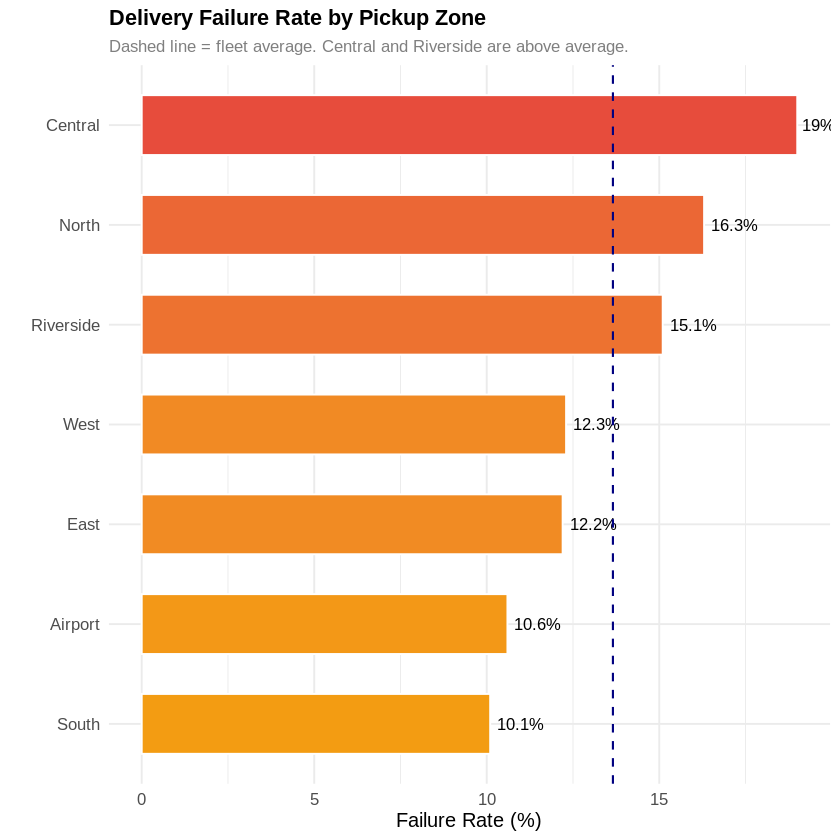

In [19]:
# Zone analysis — using cleaned zone names from Python
p4 <- ggplot(q7, aes(x = reorder(zone, failure_rate_pct), y = failure_rate_pct,
                      fill = failure_rate_pct)) +
  geom_bar(stat = "identity", width = 0.6, colour = "white") +
  geom_text(aes(label = paste0(failure_rate_pct, "%")),
            hjust = -0.15, size = 3.5) +
  scale_fill_gradient(low = "#f39c12", high = "#e74c3c", guide = "none") +
  coord_flip() +
  geom_hline(yintercept = mean(q7$failure_rate_pct),
             linetype = "dashed", colour = "navy", linewidth = 0.6) +
  labs(title    = "Delivery Failure Rate by Pickup Zone",
       subtitle = "Dashed line = fleet average. Central and Riverside are above average.",
       x = NULL, y = "Failure Rate (%)") +
  theme(plot.subtitle = element_text(size = 10, colour = "grey50"))

print(p4)
ggsave("r_chart4_zone_failure.png", p4, width = 8, height = 5, dpi = 150)
cat("Chart saved.\n")

### Chart 5 — Driver Override Count Distribution

Chart saved.


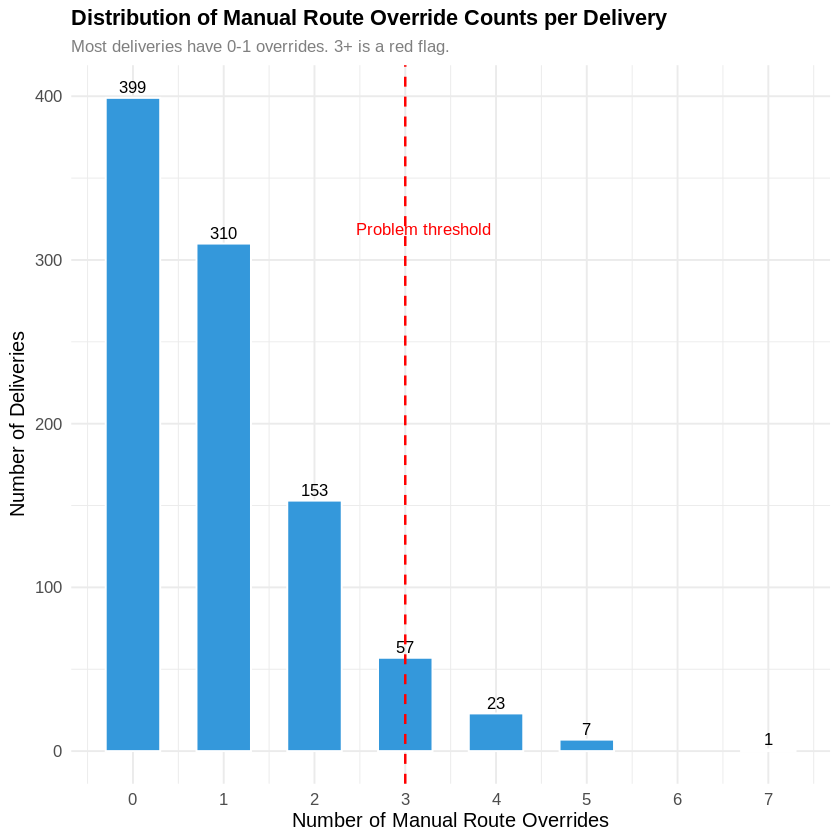

In [20]:
# Distribution of manual route overrides — is this normal or are outliers a problem?
override_dist <- as.data.frame(table(deliveries$manual_route_override_count))
names(override_dist) <- c("override_count", "frequency")
override_dist$override_count <- as.numeric(as.character(override_dist$override_count))

p5 <- ggplot(override_dist, aes(x = override_count, y = frequency)) +
  geom_bar(stat = "identity", fill = "#3498db", colour = "white", width = 0.6) +
  geom_text(aes(label = frequency), vjust = -0.4, size = 3.5) +
  labs(title    = "Distribution of Manual Route Override Counts per Delivery",
       subtitle = "Most deliveries have 0-1 overrides. 3+ is a red flag.",
       x = "Number of Manual Route Overrides", y = "Number of Deliveries") +
  scale_x_continuous(breaks = 0:7) +
  geom_vline(xintercept = 3, linetype = "dashed", colour = "red", linewidth = 0.7) +
  annotate("text", x = 3.2, y = max(override_dist$frequency) * 0.8,
           label = "Problem threshold", colour = "red", size = 3.5) +
  theme(plot.subtitle = element_text(size = 10, colour = "grey50"))

print(p5)
ggsave("r_chart5_override_dist.png", p5, width = 8, height = 5, dpi = 150)
cat("Chart saved.\n")

### Chart 6 — Complaint Volume by Type and Severity (Heatmap)

Chart saved.


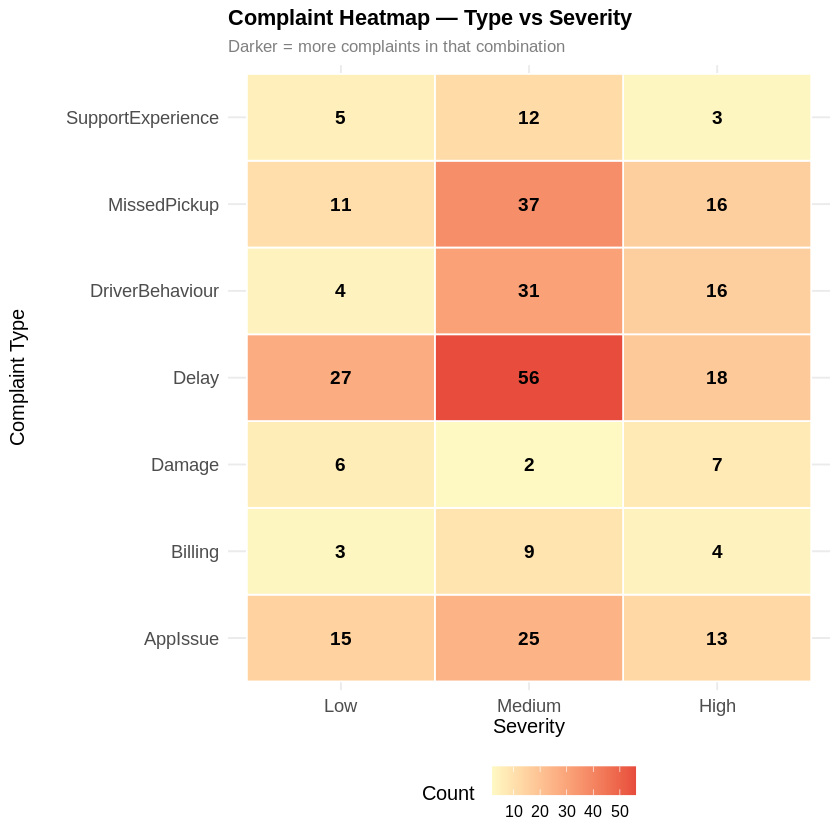

In [21]:
# Heatmap showing which complaint types are most severe
comp_heat <- complaints %>%
  group_by(complaint_type, severity) %>%
  summarise(count = n(), .groups = "drop")

comp_heat$severity <- factor(comp_heat$severity, levels = c("Low","Medium","High"))

p6 <- ggplot(comp_heat, aes(x = severity, y = complaint_type, fill = count)) +
  geom_tile(colour = "white", linewidth = 0.5) +
  geom_text(aes(label = count), size = 4, fontface = "bold") +
  scale_fill_gradient(low = "#fef9c3", high = "#e74c3c", name = "Count") +
  labs(title    = "Complaint Heatmap — Type vs Severity",
       subtitle = "Darker = more complaints in that combination",
       x = "Severity", y = "Complaint Type") +
  theme(plot.subtitle = element_text(size = 10, colour = "grey50"),
        axis.text     = element_text(size = 11))

print(p6)
ggsave("r_chart6_complaint_heatmap.png", p6, width = 8, height = 5, dpi = 150)
cat("Chart saved.\n")

### Chart 7 — Statistical Summary: Driver Rating vs Delivery Outcome

Chart saved.

ANOVA — Does driver rating differ significantly across delivery outcomes?
                 Df Sum Sq Mean Sq F value  Pr(>F)   
delivery_status   2   1.86  0.9316    5.52 0.00414 **
Residuals       947 159.84  0.1688                   
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Interpretation: If p > 0.05, driver rating alone does not explain delivery failures.
This shifts the blame to route planning and hub management.


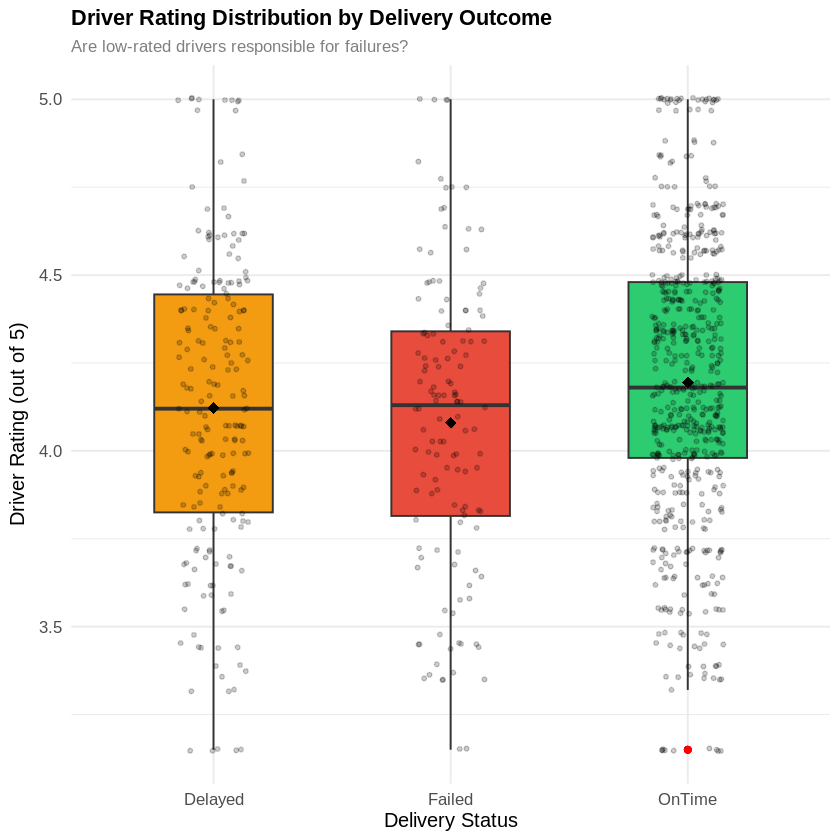

In [22]:
# Box plot — do higher-rated drivers achieve better delivery outcomes?
driver_outcome <- deliveries %>%
  left_join(drivers[, c("driver_id","driver_rating","training_score")], by = "driver_id") %>%
  filter(!is.na(driver_rating))

p7 <- ggplot(driver_outcome,
             aes(x = delivery_status, y = driver_rating, fill = delivery_status)) +
  geom_boxplot(outlier.colour = "red", outlier.size = 1.5, width = 0.5) +
  geom_jitter(width = 0.15, alpha = 0.2, size = 1) +
  scale_fill_manual(values = c("OnTime" = "#2ecc71",
                               "Delayed" = "#f39c12",
                               "Failed"  = "#e74c3c"),
                    guide = "none") +
  labs(title    = "Driver Rating Distribution by Delivery Outcome",
       subtitle = "Are low-rated drivers responsible for failures?",
       x = "Delivery Status", y = "Driver Rating (out of 5)") +
  stat_summary(fun = mean, geom = "point", shape = 18, size = 3, colour = "black") +
  theme(plot.subtitle = element_text(size = 10, colour = "grey50"))

print(p7)
ggsave("r_chart7_driver_rating.png", p7, width = 7, height = 5, dpi = 150)
cat("Chart saved.\n")

# Quick ANOVA to test if driver_rating differs across delivery status groups
anova_result <- aov(driver_rating ~ delivery_status, data = driver_outcome)
cat("\nANOVA — Does driver rating differ significantly across delivery outcomes?\n")
print(summary(anova_result))
cat("\nInterpretation: If p > 0.05, driver rating alone does not explain delivery failures.\n")
cat("This shifts the blame to route planning and hub management.\n")

### Chart 8 — Correlation Matrix (Numeric Variables)

agg_record_e135997642 
                    2

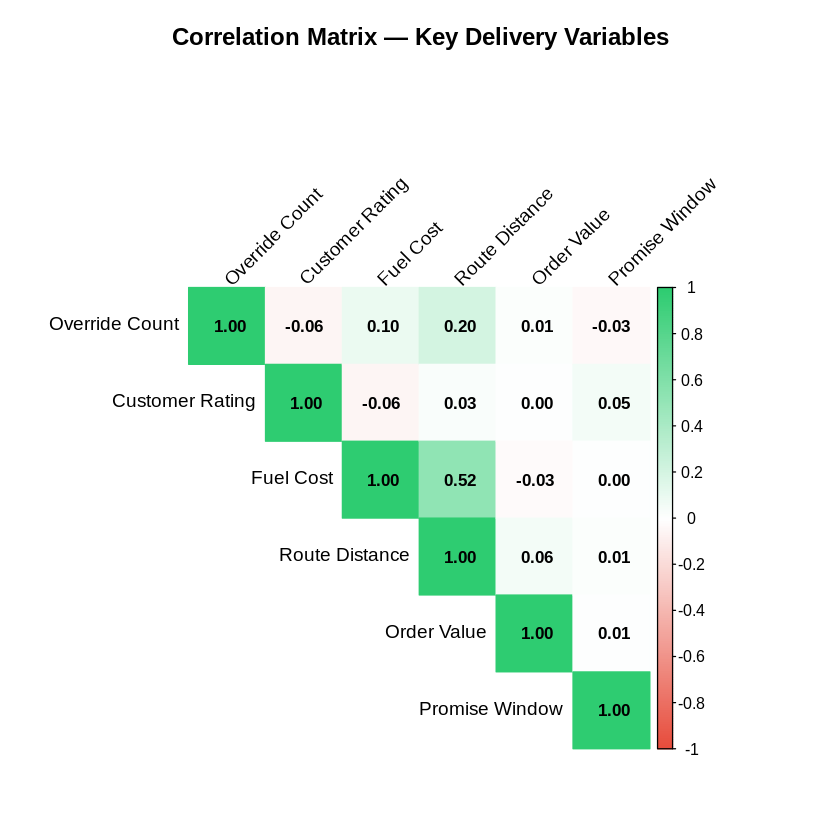

In [27]:
# Correlation matrix across key numeric delivery variables
# Helps identify which factors move together

corr_data <- deliveries %>%
  left_join(orders[, c("order_id","order_value","promised_window_hours")], by = "order_id") %>%
  select(manual_route_override_count, customer_rating_post_delivery,
         fuel_or_charge_cost, route_distance_km,
         order_value, promised_window_hours) %>%
  na.omit()

corr_matrix <- cor(corr_data)

# Rename columns
colnames(corr_matrix) <- rownames(corr_matrix) <- c(
  "Override Count",
  "Customer Rating",
  "Fuel Cost",
  "Route Distance",
  "Order Value",
  "Promise Window"
)

# Save to PNG
png("r_chart8_correlation.png", width = 900, height = 800, res = 130)
corrplot(corr_matrix,
         method      = "color",
         type        = "upper",
         addCoef.col = "black",
         number.cex  = 0.85,
         tl.col      = "black",
         tl.srt      = 45,
         tl.cex      = 0.95,
         col         = colorRampPalette(c("#e74c3c", "white", "#2ecc71"))(200),
         title       = "Correlation Matrix — Key Delivery Variables",
         mar         = c(0, 0, 3, 0))
dev.off()

# Display inline in Colab
corrplot(corr_matrix,
         method      = "color",
         type        = "upper",
         addCoef.col = "black",
         number.cex  = 0.85,
         tl.col      = "black",
         tl.srt      = 45,
         tl.cex      = 0.95,
         col         = colorRampPalette(c("#e74c3c", "white", "#2ecc71"))(200),
         title       = "Correlation Matrix — Key Delivery Variables",
         mar         = c(0, 0, 3, 0))

## Section 6 — Statistical Analysis Summary

In [24]:
# Summary statistics for the key numeric variables in deliveries
cat("Summary statistics — deliveries numeric columns:\n")
summary(deliveries[, c("manual_route_override_count",
                        "customer_rating_post_delivery",
                        "fuel_or_charge_cost",
                        "route_distance_km")])

Summary statistics — deliveries numeric columns:


 manual_route_override_count customer_rating_post_delivery fuel_or_charge_cost
 Min.   :0.0000              Min.   :1.000                 Min.   : 2.500     
 1st Qu.:0.0000              1st Qu.:3.373                 1st Qu.: 9.925     
 Median :1.0000              Median :4.040                 Median :12.645     
 Mean   :0.9695              Mean   :3.867                 Mean   :12.841     
 3rd Qu.:2.0000              3rd Qu.:4.550                 3rd Qu.:15.697     
 Max.   :7.0000              Max.   :5.000                 Max.   :29.430     
 route_distance_km
 Min.   : 1.200   
 1st Qu.: 9.135   
 Median :12.840   
 Mean   :13.909   
 3rd Qu.:16.835   
 Max.   :41.940   

In [25]:
# T-test: Is customer rating significantly lower for Failed vs OnTime deliveries?

failed_ratings <- deliveries$customer_rating_post_delivery[
  deliveries$delivery_status == "Failed" & !is.na(deliveries$customer_rating_post_delivery)]

ontime_ratings <- deliveries$customer_rating_post_delivery[
  deliveries$delivery_status == "OnTime" & !is.na(deliveries$customer_rating_post_delivery)]

cat(sprintf("Failed group  : %d observations, mean = %.2f\n",
            length(failed_ratings), mean(failed_ratings)))
cat(sprintf("OnTime group  : %d observations, mean = %.2f\n",
            length(ontime_ratings), mean(ontime_ratings)))

# Only run t.test if both groups have enough observations (minimum 2)
if (length(failed_ratings) >= 2 && length(ontime_ratings) >= 2) {
  t_result <- t.test(failed_ratings, ontime_ratings, alternative = "less")
  cat("\nT-test: Customer rating — Failed vs OnTime deliveries\n")
  print(t_result)
  cat("\nInterpretation:\n")
  if (t_result$p.value < 0.05) {
    cat("p < 0.05 — Significant. Failed deliveries receive statistically lower ratings.\n")
    cat("This confirms customer experience correlates with operational outcomes.\n")
  } else {
    cat("p >= 0.05 — Not significant at 95% confidence level.\n")
    cat("Customer ratings alone cannot reliably distinguish failed vs on-time deliveries.\n")
  }
} else {
  cat("\nInsufficient data in one group for t.test.\n")
  cat("Check that delivery_status values match 'OnTime' and 'Failed' exactly.\n")
  cat("Available status values:", paste(unique(deliveries$delivery_status), collapse=", "), "\n")
}

Failed group  : 132 observations, mean = 3.06
OnTime group  : 616 observations, mean = 4.28

T-test: Customer rating — Failed vs OnTime deliveries

	Welch Two Sample t-test

data:  failed_ratings and ontime_ratings
t = -15.402, df = 151.69, p-value < 2.2e-16
alternative hypothesis: true difference in means is less than 0
95 percent confidence interval:
      -Inf -1.091853
sample estimates:
mean of x mean of y 
 3.056818  4.280114 


Interpretation:
p < 0.05 — Significant. Failed deliveries receive statistically lower ratings.
This confirms customer experience correlates with operational outcomes.


In [26]:
# Close the database connection cleanly
dbDisconnect(con)
cat("\nSQLite connection closed.\n")
cat("All SQL queries and R charts completed.\n")
cat("\nCharts saved:\n")
cat("  r_chart1_hub_failure.png\n")
cat("  r_chart2_hub_stacked.png\n")
cat("  r_chart3_service_scatter.png\n")
cat("  r_chart4_zone_failure.png\n")
cat("  r_chart5_override_dist.png\n")
cat("  r_chart6_complaint_heatmap.png\n")
cat("  r_chart7_driver_rating.png\n")
cat("  r_chart8_correlation.png\n")


SQLite connection closed.
All SQL queries and R charts completed.

Charts saved:
  r_chart1_hub_failure.png
  r_chart2_hub_stacked.png
  r_chart3_service_scatter.png
  r_chart4_zone_failure.png
  r_chart5_override_dist.png
  r_chart6_complaint_heatmap.png
  r_chart7_driver_rating.png
  r_chart8_correlation.png
